**Run note:** Execute cells top-to-bottom. This is **Phase 3** — upgrades from CLIP ViT-B/32 (512-dim) to **CLIP ViT-L/14 (768-dim)** for significantly better visual representations. Trains from scratch (new architecture). On Kaggle, ensure GPU accelerator is enabled (T4/P100).

# 09c — AUROC Optimization · Phase 3: CLIP ViT-L/14 Backbone Upgrade

Previous best: NB-09 Phase 1 AUROC = **0.7306** (ViT-B/32, 512-dim).

ViT-L/14 produces 768-dim embeddings with a 24-layer vision transformer vs 12-layer in ViT-B/32.
This is the single biggest lever available without external data or model ensembles.

| Component | ViT-B/32 (old) | ViT-L/14 (new) |
|-----------|---------------|----------------|
| Vision layers | 12 | 24 |
| Text layers | 12 | 12 |
| Embed dim | 512 | 768 |
| Patch size | 32×32 | 14×14 |
| Total params | 151M | 428M |

## Strategy
1. **Phase 3a** — Train with frozen CLIP backbone (only cross-attention head learns)
2. **Phase 3b** — Unfreeze last 4 vision + 4 text layers with discriminative LR
3. **Ensemble** — Average Phase 3b + NB-09 (ViT-B/32) for diversity boost

## Checkpoint flow
```
NB-09c Phase 3a →  vitl14_frozen_best.pt      (head-only warmup)
NB-09c Phase 3b →  vitl14_unfrozen_best.pt     (target: > 0.7306)
Ensemble        →  average with NB-09 checkpoint
```

In [1]:
import os
import json
import math
import random
import re
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter, ImageEnhance
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from torchvision import transforms
from transformers import CLIPModel, CLIPProcessor

ON_KAGGLE = Path('/kaggle/input').is_dir()
JSONL_CANDIDATES = {
    'train': ['train.jsonl'],
    'dev': ['dev.jsonl', 'dev_seen.jsonl', 'dev_unseen.jsonl'],
    'test': ['test.jsonl', 'test_seen.jsonl', 'test_unseen.jsonl'],
}
IMAGE_DIR_CANDIDATES = ('img', 'images')

def _has_image_dir(path: Path) -> bool:
    return any((path / name).is_dir() for name in IMAGE_DIR_CANDIDATES)

def _has_any_jsonl(path: Path, names) -> bool:
    return any((path / name).is_file() for name in names)

def _looks_like_dataset_root(path: Path) -> bool:
    return path.is_dir() and _has_image_dir(path) and _has_any_jsonl(path, JSONL_CANDIDATES['train'])

def detect_data_dir():
    for env_name in ('KAGGLE_DATA_DIR', 'META_HATEFUL_MEME_DATA_DIR'):
        env_dir = os.environ.get(env_name, '').strip()
        if env_dir and _looks_like_dataset_root(Path(env_dir)):
            return Path(env_dir), f'env:{env_name}'
    kaggle_input = Path('/kaggle/input')
    default_candidate = kaggle_input / 'meta-hateful-meme-detection' / 'data'
    if _looks_like_dataset_root(default_candidate):
        return default_candidate, 'default:/kaggle/input/meta-hateful-meme-detection/data'
    if ON_KAGGLE:
        for train_jsonl in sorted(kaggle_input.rglob('train.jsonl')):
            candidate = train_jsonl.parent
            if _looks_like_dataset_root(candidate):
                return candidate, f'auto:{candidate}'
        for candidate in sorted(kaggle_input.rglob('*')):
            if candidate.is_dir() and _looks_like_dataset_root(candidate):
                return candidate, f'auto:{candidate}'
    for candidate in (Path.cwd() / 'data', Path.cwd().parent / 'data', Path.cwd(), Path.cwd().parent):
        if _looks_like_dataset_root(candidate):
            return candidate, f'local:{candidate}'
    return None, 'not-found'

def resolve_split(base_dir, names):
    base_dir = Path(base_dir)
    for name in names:
        path = base_dir / name
        if path.is_file():
            return path
    for name in names:
        matches = sorted(base_dir.rglob(name))
        if matches:
            return matches[0]
    return None

DATA_DIR, data_source = detect_data_dir()
if DATA_DIR is None:
    raise FileNotFoundError('Dataset not found. Set KAGGLE_DATA_DIR or META_HATEFUL_MEME_DATA_DIR.')

TRAIN_PATH = resolve_split(DATA_DIR, JSONL_CANDIDATES['train'])
DEV_PATH = resolve_split(DATA_DIR, JSONL_CANDIDATES['dev'])
if TRAIN_PATH is None or DEV_PATH is None:
    raise FileNotFoundError(f'Expected train/dev splits under {DATA_DIR}')

BASE_OUTPUT_DIR = Path('/kaggle/working') if ON_KAGGLE else Path.cwd() / 'outputs'
OUTPUT_DIR = Path('/kaggle/working') if ON_KAGGLE else Path.cwd() / 'outputs' / 'training_vitl14'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
REFERENCE_BEST_AUROC = 0.7306   # NB-09 best (ViT-B/32)

# ── Auto-detect locally cached CLIP model (avoids HF download hangs) ──
def find_local_clip_model(model_name='clip-vit-large-patch14'):
    if ON_KAGGLE:
        for root in sorted(Path('/kaggle/input').rglob(model_name)):
            if (root / 'config.json').exists():
                print(f'Found local CLIP model: {root}')
                return str(root)
    return 'openai/clip-vit-large-patch14'

CLIP_MODEL_PATH = find_local_clip_model()
print('CLIP model path:', CLIP_MODEL_PATH)

# ── Phase 3 config: ViT-L/14 ──────────────────────────────────────────
CFG = {
    'clip_model': CLIP_MODEL_PATH,
    'batch_size': 16 if torch.cuda.is_available() else 4,
    'max_text_len': 77,
    'seed': 42,
    # ViT-L/14 produces 768-dim embeddings
    'embed_dim': 768,
    'num_heads': 8,
    'dropout': 0.3,
    # Phase 3a: frozen backbone (head-only warmup)
    'phase3a_epochs': 8,
    'phase3a_lr': 3e-4,
    'phase3a_patience': 4,
    # Phase 3b: unfreeze + discriminative LR
    'phase3b_epochs': 15,
    'encoder_lr': 2e-6,
    'head_lr': 1e-4,
    'weight_decay': 0.01,
    'warmup_ratio': 0.10,
    'unfreeze_vision_layers': 4,
    'unfreeze_text_layers': 4,
    # Loss & regularization
    'focal_gamma': 2.0,
    'label_smoothing': 0.1,
    'grad_clip': 1.0,
    'ema_decay': 0.999,
    'grad_accum': 4,   # effective batch = 16 * 4 = 64
    'patience': 6,
    # Augmentation
    'image_aug_prob': 0.35,
    'text_aug_prob': 0.25,
}

def set_seeds(seed=CFG['seed']):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seeds()
print('DATA_DIR  :', DATA_DIR)
print('Source    :', data_source)
print('Output    :', OUTPUT_DIR)
print('Device    :', DEVICE)
print('Reference :', REFERENCE_BEST_AUROC, '(NB-09 ViT-B/32)')
print('Backbone  :', CFG['clip_model'])
print('Embed dim :', CFG['embed_dim'])
print('Config    :', CFG)

Found local CLIP model: /kaggle/input/notebooks/muddybuddy/notebookc4efc44f42/clip-vit-large-patch14
CLIP model path: /kaggle/input/notebooks/muddybuddy/notebookc4efc44f42/clip-vit-large-patch14
DATA_DIR  : /kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data
Source    : auto:/kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data
Output    : /kaggle/working
Device    : cuda
Reference : 0.7306 (NB-09 ViT-B/32)
Backbone  : /kaggle/input/notebooks/muddybuddy/notebookc4efc44f42/clip-vit-large-patch14
Embed dim : 768
Config    : {'clip_model': '/kaggle/input/notebooks/muddybuddy/notebookc4efc44f42/clip-vit-large-patch14', 'batch_size': 16, 'max_text_len': 77, 'seed': 42, 'embed_dim': 768, 'num_heads': 8, 'dropout': 0.3, 'phase3a_epochs': 8, 'phase3a_lr': 0.0003, 'phase3a_patience': 4, 'phase3b_epochs': 15, 'encoder_lr': 2e-06, 'head_lr': 0.0001, 'weight_decay': 0.01, 'warmup_ratio': 0.1, 'unfreeze_vision_layers': 4, 'unfreeze_text_layers': 4, 'focal_gamma': 2.0, 'l

In [2]:
# ── Data loading & preprocessing ─────────────────────────────────────
def load_jsonl(path):
    with open(path, encoding='utf-8') as handle:
        return pd.DataFrame([json.loads(line) for line in handle if line.strip()])

def clean_text(text):
    if not isinstance(text, str):
        return '[no text]'
    text = re.sub(r'https?://\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#(\w+)', r' \1 ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text or '[no text]'

def resolve_image_path(data_dir, image_ref):
    data_dir = Path(data_dir)
    image_ref = Path(str(image_ref))
    candidates = []
    if image_ref.is_absolute():
        candidates.append(image_ref)
    candidates.extend([data_dir / image_ref, data_dir.parent / image_ref])
    if image_ref.parts:
        if image_ref.parts[0] in {'img', 'images'} and len(image_ref.parts) > 1:
            stripped = Path(*image_ref.parts[1:])
            candidates.extend([data_dir / stripped, data_dir.parent / stripped])
        elif image_ref.parts[0] not in {'img', 'images'}:
            candidates.extend([
                data_dir / 'img' / image_ref,
                data_dir / 'images' / image_ref,
                data_dir.parent / 'img' / image_ref,
                data_dir.parent / 'images' / image_ref,
            ])
    seen = set()
    for candidate in candidates:
        key = str(candidate)
        if key in seen:
            continue
        seen.add(key)
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f'Could not find image {image_ref} relative to {data_dir}')

train_df = load_jsonl(TRAIN_PATH)
dev_df = load_jsonl(DEV_PATH)
for frame in (train_df, dev_df):
    frame['clean_text'] = frame['text'].apply(clean_text)

print(f'Train={len(train_df):,}, Dev={len(dev_df):,}')
print('Train label counts:', train_df['label'].value_counts().sort_index().to_dict())

Train=8,500, Dev=500
Train label counts: {0: 5450, 1: 3050}


In [3]:
# ── Dataset & DataLoaders ─────────────────────────────────────────────
processor = CLIPProcessor.from_pretrained(CFG['clip_model'])
print(f'Processor loaded from: {CFG["clip_model"]}')

train_image_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.2),
    transforms.RandomApply([transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15)], p=0.4),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.15),
])

def perturb_text(text):
    if random.random() > CFG['text_aug_prob']:
        return text
    tokens = text.split()
    if not tokens:
        return text
    mode = random.choice(['case', 'punct', 'swap', 'space'])
    if mode == 'case':
        idx = random.randrange(len(tokens))
        token = tokens[idx]
        tokens[idx] = token.upper() if token.lower() == token else token.lower()
        return ' '.join(tokens)
    if mode == 'punct':
        idx = random.randrange(len(tokens))
        tokens[idx] = tokens[idx] + random.choice(['!', '?', '.', '...'])
        return ' '.join(tokens)
    if mode == 'swap' and len(tokens) >= 2:
        idx = random.randrange(len(tokens) - 1)
        tokens[idx], tokens[idx + 1] = tokens[idx + 1], tokens[idx]
        return ' '.join(tokens)
    return ' '.join(list(text)) if mode == 'space' else text

def perturb_image(image):
    if random.random() > CFG['image_aug_prob']:
        return image
    mode = random.choice(['blur', 'noise', 'contrast', 'none'])
    if mode == 'blur':
        return image.filter(ImageFilter.GaussianBlur(radius=1.0))
    if mode == 'contrast':
        return ImageEnhance.Contrast(image).enhance(random.uniform(0.85, 1.15))
    if mode == 'noise':
        arr = np.array(image).astype(np.float32)
        arr += np.random.normal(0, 8, size=arr.shape)
        arr = np.clip(arr, 0, 255).astype(np.uint8)
        return Image.fromarray(arr)
    return image


class MemeDataset(Dataset):
    def __init__(self, df, data_dir, processor, training=False):
        self.df = df.reset_index(drop=True)
        self.data_dir = data_dir
        self.processor = processor
        self.training = training

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            image = Image.open(resolve_image_path(self.data_dir, row['img'])).convert('RGB')
        except Exception:
            image = Image.new('RGB', (224, 224), 128)

        text = row['clean_text']
        if self.training:
            image = train_image_transform(image)
            image = perturb_image(image)
            text = perturb_text(text)

        encoded = self.processor(
            text=[text], images=image, return_tensors='pt',
            padding='max_length', truncation=True, max_length=CFG['max_text_len'],
        )
        return {
            'pixel_values': encoded['pixel_values'].squeeze(0),
            'input_ids': encoded['input_ids'].squeeze(0),
            'attention_mask': encoded['attention_mask'].squeeze(0),
            'label': torch.tensor(int(row['label']), dtype=torch.long),
        }


train_ds = MemeDataset(train_df, DATA_DIR, processor, training=True)
dev_ds   = MemeDataset(dev_df,   DATA_DIR, processor, training=False)

# Balanced sampling
labels = train_df['label'].values
n_pos = int((labels == 1).sum())
n_neg = int((labels == 0).sum())
w_pos = len(labels) / (2.0 * n_pos)
w_neg = len(labels) / (2.0 * n_neg)
sample_weights = [w_neg if lab == 0 else w_pos for lab in labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], sampler=sampler,
                          num_workers=2, pin_memory=True)
dev_loader   = DataLoader(dev_ds, batch_size=CFG['batch_size'] * 2, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f'Train batches: {len(train_loader)} | Dev batches: {len(dev_loader)}')

Processor loaded from: /kaggle/input/notebooks/muddybuddy/notebookc4efc44f42/clip-vit-large-patch14
Train batches: 532 | Dev batches: 16


In [4]:
# ── Model Architecture (ViT-L/14, 768-dim) ───────────────────────────

def _ensure_tensor(out):
    if isinstance(out, torch.Tensor):
        return out
    if hasattr(out, 'pooler_output') and out.pooler_output is not None:
        return out.pooler_output
    if hasattr(out, 'last_hidden_state'):
        return out.last_hidden_state[:, 0]
    return out[0]


class CLIPEncoder(nn.Module):
    def __init__(self, model_name=CFG['clip_model']):
        super().__init__()
        print(f'  Loading CLIP model: {model_name} ...')
        self.clip = CLIPModel.from_pretrained(model_name)
        print(f'  CLIP model loaded.')
        for p in self.clip.parameters():
            p.requires_grad_(False)

    def forward(self, pixel_values, input_ids, attention_mask):
        i = F.normalize(_ensure_tensor(
            self.clip.get_image_features(pixel_values=pixel_values)), dim=-1)
        t = F.normalize(_ensure_tensor(
            self.clip.get_text_features(input_ids=input_ids, attention_mask=attention_mask)), dim=-1)
        return i, t


class CrossAttentionFusion(nn.Module):
    def __init__(self, d=768, heads=8, drop=0.1):
        super().__init__()
        self.i2t = nn.MultiheadAttention(d, heads, dropout=drop, batch_first=True)
        self.t2i = nn.MultiheadAttention(d, heads, dropout=drop, batch_first=True)
        self.ni  = nn.LayerNorm(d)
        self.nt  = nn.LayerNorm(d)

    def forward(self, i, t):
        is_ = i.unsqueeze(1); ts = t.unsqueeze(1)
        ic, ia = self.i2t(is_, ts, ts)
        tc, ta = self.t2i(ts, is_, is_)
        return torch.cat([self.ni(i + ic.squeeze(1)), self.nt(t + tc.squeeze(1))], dim=-1), ia, ta


class ClassificationHead(nn.Module):
    def __init__(self, d=1536, drop=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 512), nn.GELU(), nn.Dropout(drop),
            nn.Linear(512, 256), nn.GELU(), nn.Dropout(drop),
            nn.Linear(256, 2),
        )

    def forward(self, x):
        return self.net(x)


class HatefulMemeClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = CLIPEncoder()
        self.fusion  = CrossAttentionFusion(CFG['embed_dim'], CFG['num_heads'], CFG['dropout'])
        self.head    = ClassificationHead(CFG['embed_dim'] * 2, CFG['dropout'])

    def forward(self, pixel_values, input_ids, attention_mask):
        i, t = self.encoder(pixel_values, input_ids, attention_mask)
        fused, ia, ta = self.fusion(i, t)
        return self.head(fused), ia, ta


def unfreeze_last_layers(model, vision_n=4, text_n=4):
    clip = model.encoder.clip
    # ViT-L/14 has 24 vision layers, 12 text layers
    for layer in clip.vision_model.encoder.layers[-vision_n:]:
        for p in layer.parameters():
            p.requires_grad_(True)
    for layer in clip.text_model.encoder.layers[-text_n:]:
        for p in layer.parameters():
            p.requires_grad_(True)
    for module in [
        clip.vision_model.post_layernorm,
        clip.text_model.final_layer_norm,
        clip.visual_projection,
        clip.text_projection,
    ]:
        for p in module.parameters():
            p.requires_grad_(True)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'Trainable: {trainable:,} / {total:,}  ({100 * trainable / total:.1f}%)')
    print(f'  Unfrozen: last {vision_n} vision blocks + last {text_n} text blocks + projections')


print('Building HatefulMemeClassifier (ViT-L/14) ...')
model = HatefulMemeClassifier()
print(f'Model built. Total params: {sum(p.numel() for p in model.parameters()):,}')
model = model.to(DEVICE)
print(f'Model on {DEVICE} \u2014 ready for Phase 3a (frozen backbone).')

Building HatefulMemeClassifier (ViT-L/14) ...
  Loading CLIP model: /kaggle/input/notebooks/muddybuddy/notebookc4efc44f42/clip-vit-large-patch14 ...


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

  CLIP model loaded.
Model built. Total params: 433,263,107
Model on cuda — ready for Phase 3a (frozen backbone).


In [5]:
# ── Loss, EMA, Evaluation ─────────────────────────────────────────────

class FocalLossWithSmoothing(nn.Module):
    def __init__(self, gamma=2.0, smoothing=0.1):
        super().__init__()
        self.gamma     = gamma
        self.smoothing = smoothing

    def forward(self, logits, targets):
        n = logits.size(1)
        ce_hard      = F.cross_entropy(logits, targets, reduction='none')
        focal_weight = (1.0 - torch.exp(-ce_hard)) ** self.gamma
        log_probs    = F.log_softmax(logits, dim=-1)
        smooth_tgts  = torch.full_like(log_probs, self.smoothing / (n - 1))
        smooth_tgts.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        smooth_ce    = -(smooth_tgts * log_probs).sum(dim=-1)
        return (focal_weight * smooth_ce).mean()


class EMA:
    def __init__(self, model, decay=0.999):
        self.decay  = decay
        self.shadow = {n: p.data.clone() for n, p in model.named_parameters() if p.requires_grad}
        self.backup = {}

    @torch.no_grad()
    def update(self, model):
        for n, p in model.named_parameters():
            if p.requires_grad and n in self.shadow:
                self.shadow[n].mul_(self.decay).add_(p.data, alpha=1 - self.decay)

    def apply(self, model):
        self.backup = {}
        for n, p in model.named_parameters():
            if n in self.shadow:
                self.backup[n] = p.data.clone()
                p.data.copy_(self.shadow[n])

    def restore(self, model):
        for n, p in model.named_parameters():
            if n in self.backup:
                p.data.copy_(self.backup[n])


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    for batch in loader:
        pv  = batch['pixel_values'].to(DEVICE)
        ids = batch['input_ids'].to(DEVICE)
        am  = batch['attention_mask'].to(DEVICE)
        with autocast(enabled=(DEVICE.type == 'cuda')):
            logits, _, _ = model(pv, ids, am)
        probs = torch.softmax(logits.float(), dim=-1)[:, 1]
        all_probs.extend(probs.cpu().numpy().tolist())
        all_preds.extend(logits.argmax(dim=-1).cpu().numpy().tolist())
        all_labels.extend(batch['label'].numpy().tolist())
    return {
        'auroc': roc_auc_score(all_labels, all_probs),
        'f1': f1_score(all_labels, all_preds, pos_label=1),
        'accuracy': accuracy_score(all_labels, all_preds),
    }

print('Utilities ready.')

Utilities ready.


## Phase 3a — Frozen Backbone (Head-Only Warmup)

Train only the cross-attention fusion + classification head with the CLIP backbone fully frozen.
This gives the randomly-initialized head a good starting point before unfreezing.

In [6]:
def train_phase3a():
    set_seeds()
    # Only head params are trainable (encoder frozen)
    head_params = [p for p in model.parameters() if p.requires_grad]
    print(f'Phase 3a trainable params: {sum(p.numel() for p in head_params):,}')

    optimizer = torch.optim.AdamW(head_params, lr=CFG['phase3a_lr'], weight_decay=CFG['weight_decay'])
    accum = CFG['grad_accum']
    total_steps = (len(train_loader) // accum) * CFG['phase3a_epochs']
    warmup_steps = int(total_steps * CFG['warmup_ratio'])

    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    scaler    = GradScaler(enabled=(DEVICE.type == 'cuda'))
    criterion = FocalLossWithSmoothing(CFG['focal_gamma'], CFG['label_smoothing']).to(DEVICE)
    ema       = EMA(model, decay=CFG['ema_decay'])

    history = {'train_loss': [], 'val_auroc': [], 'val_f1': [], 'val_accuracy': []}
    best_auroc = -1.0
    best_path = OUTPUT_DIR / 'vitl14_frozen_best.pt'
    patience_left = CFG['phase3a_patience']

    for epoch in range(1, CFG['phase3a_epochs'] + 1):
        model.train()
        epoch_loss = 0.0
        start = time.time()
        optimizer.zero_grad(set_to_none=True)

        for step, batch in enumerate(train_loader):
            pv     = batch['pixel_values'].to(DEVICE)
            ids    = batch['input_ids'].to(DEVICE)
            am     = batch['attention_mask'].to(DEVICE)
            labels = batch['label'].to(DEVICE)

            with autocast(enabled=(DEVICE.type == 'cuda')):
                logits, _, _ = model(pv, ids, am)
                loss = criterion(logits, labels) / accum

            scaler.scale(loss).backward()
            epoch_loss += loss.item() * accum

            if (step + 1) % accum == 0 or (step + 1) == len(train_loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(head_params, CFG['grad_clip'])
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)
                ema.update(model)

        ema.apply(model)
        metrics = evaluate(model, dev_loader)
        ema.restore(model)

        avg_loss = epoch_loss / max(1, len(train_loader))
        history['train_loss'].append(avg_loss)
        history['val_auroc'].append(metrics['auroc'])
        history['val_f1'].append(metrics['f1'])
        history['val_accuracy'].append(metrics['accuracy'])

        elapsed = time.time() - start
        print(f"Phase 3a Epoch {epoch:02d}/{CFG['phase3a_epochs']} | loss={avg_loss:.4f} "
              f"| AUROC={metrics['auroc']:.4f} | F1={metrics['f1']:.4f} "
              f"| ACC={metrics['accuracy']:.4f} | {elapsed:.0f}s")

        if metrics['auroc'] > best_auroc:
            best_auroc = metrics['auroc']
            patience_left = CFG['phase3a_patience']
            ema.apply(model)
            torch.save(model.state_dict(), best_path)
            ema.restore(model)
            print(f'  => new best AUROC {best_auroc:.4f}  (saved)')
        else:
            patience_left -= 1
            print(f'  => no improvement, patience left: {patience_left}')
            if patience_left <= 0:
                print('  Early stop.')
                break

    return history, best_auroc, best_path


history_3a, best_auroc_3a, best_path_3a = train_phase3a()
print()
print('=' * 55)
print(f'Phase 3a (frozen) best AUROC : {best_auroc_3a:.4f}')
print(f'Reference NB-09 AUROC        : {REFERENCE_BEST_AUROC}')
print('=' * 55)

Phase 3a trainable params: 5,646,594


/tmp/ipykernel_25/113594912.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler(enabled=(DEVICE.type == 'cuda'))
/tmp/ipykernel_25/113594912.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_25/2421602584.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):


Phase 3a Epoch 01/8 | loss=0.1527 | AUROC=0.5844 | F1=0.6696 | ACC=0.5500 | 180s
  => new best AUROC 0.5844  (saved)


/tmp/ipykernel_25/113594912.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_25/2421602584.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):


Phase 3a Epoch 02/8 | loss=0.1336 | AUROC=0.6777 | F1=0.6629 | ACC=0.6400 | 172s
  => new best AUROC 0.6777  (saved)


...

Phase 3a Epoch 06/8 | loss=0.0809 | AUROC=0.7437 | F1=0.5849 | ACC=0.6480 | 165s
  => new best AUROC 0.7437  (saved)


/tmp/ipykernel_25/113594912.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_25/2421602584.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):


Phase 3a Epoch 07/8 | loss=0.0709 | AUROC=0.7512 | F1=0.5943 | ACC=0.6560 | 164s
  => new best AUROC 0.7512  (saved)


/tmp/ipykernel_25/113594912.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_25/2421602584.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):


Phase 3a Epoch 08/8 | loss=0.0667 | AUROC=0.7569 | F1=0.6089 | ACC=0.6660 | 164s
  => new best AUROC 0.7569  (saved)

Phase 3a (frozen) best AUROC : 0.7569
Reference NB-09 AUROC        : 0.7306


## Phase 3b — Unfrozen Backbone (Fine-Tuning)

Load Phase 3a checkpoint, unfreeze last 4 vision + 4 text layers, and fine-tune with discriminative learning rates.

In [7]:
# ── Load Phase 3a checkpoint & unfreeze ───────────────────────────────
phase3a_ckpt = OUTPUT_DIR / 'vitl14_frozen_best.pt'
if phase3a_ckpt.exists():
    state = torch.load(phase3a_ckpt, map_location='cpu', weights_only=True)
    model.load_state_dict(state, strict=True)
    model = model.to(DEVICE)
    print(f'Loaded Phase 3a checkpoint: {phase3a_ckpt}')
else:
    print('WARNING: Phase 3a checkpoint not found, continuing with current weights.')

print('Unfreezing last layers ...')
unfreeze_last_layers(model, CFG['unfreeze_vision_layers'], CFG['unfreeze_text_layers'])

Loaded Phase 3a checkpoint: /kaggle/working/vitl14_frozen_best.pt
Unfreezing last layers ...
Trainable: 85,762,818 / 433,263,107  (19.8%)
  Unfrozen: last 4 vision blocks + last 4 text blocks + projections


In [8]:
def make_optimizer_phase3b(model):
    encoder_params, head_params = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if 'encoder.clip' in name:
            encoder_params.append(param)
        else:
            head_params.append(param)
    print(f"Optimizer: encoder {sum(p.numel() for p in encoder_params):,} params @ lr={CFG['encoder_lr']}")
    print(f"           head    {sum(p.numel() for p in head_params):,} params @ lr={CFG['head_lr']}")
    return torch.optim.AdamW([
        {'params': encoder_params, 'lr': CFG['encoder_lr']},
        {'params': head_params,    'lr': CFG['head_lr']},
    ], weight_decay=CFG['weight_decay'])


def train_phase3b():
    set_seeds()
    optimizer = make_optimizer_phase3b(model)
    accum = CFG['grad_accum']
    total_steps = (len(train_loader) // accum) * CFG['phase3b_epochs']
    warmup_steps = int(total_steps * CFG['warmup_ratio'])

    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    scaler    = GradScaler(enabled=(DEVICE.type == 'cuda'))
    criterion = FocalLossWithSmoothing(CFG['focal_gamma'], CFG['label_smoothing']).to(DEVICE)
    # Re-initialize EMA with the newly unfrozen params
    ema = EMA(model, decay=CFG['ema_decay'])

    history = {'train_loss': [], 'val_auroc': [], 'val_f1': [], 'val_accuracy': []}
    best_auroc = -1.0
    best_path = OUTPUT_DIR / 'vitl14_unfrozen_best.pt'
    patience_left = CFG['patience']

    for epoch in range(1, CFG['phase3b_epochs'] + 1):
        model.train()
        epoch_loss = 0.0
        start = time.time()
        optimizer.zero_grad(set_to_none=True)

        for step, batch in enumerate(train_loader):
            pv     = batch['pixel_values'].to(DEVICE)
            ids    = batch['input_ids'].to(DEVICE)
            am     = batch['attention_mask'].to(DEVICE)
            labels = batch['label'].to(DEVICE)

            with autocast(enabled=(DEVICE.type == 'cuda')):
                logits, _, _ = model(pv, ids, am)
                loss = criterion(logits, labels) / accum

            scaler.scale(loss).backward()
            epoch_loss += loss.item() * accum

            if (step + 1) % accum == 0 or (step + 1) == len(train_loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    [p for p in model.parameters() if p.requires_grad], CFG['grad_clip'])
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)
                ema.update(model)

        ema.apply(model)
        metrics = evaluate(model, dev_loader)
        ema.restore(model)

        avg_loss = epoch_loss / max(1, len(train_loader))
        history['train_loss'].append(avg_loss)
        history['val_auroc'].append(metrics['auroc'])
        history['val_f1'].append(metrics['f1'])
        history['val_accuracy'].append(metrics['accuracy'])

        elapsed = time.time() - start
        print(f"Phase 3b Epoch {epoch:02d}/{CFG['phase3b_epochs']} | loss={avg_loss:.4f} "
              f"| AUROC={metrics['auroc']:.4f} | F1={metrics['f1']:.4f} "
              f"| ACC={metrics['accuracy']:.4f} | {elapsed:.0f}s")

        if metrics['auroc'] > best_auroc:
            best_auroc = metrics['auroc']
            patience_left = CFG['patience']
            ema.apply(model)
            torch.save(model.state_dict(), best_path)
            ema.restore(model)
            print(f'  => new best AUROC {best_auroc:.4f}  (saved)')
        else:
            patience_left -= 1
            print(f'  => no improvement, patience left: {patience_left}')
            if patience_left <= 0:
                print('  Early stop.')
                break

    with open(OUTPUT_DIR / 'phase3b_history.json', 'w', encoding='utf-8') as f:
        json.dump(history, f)
    return history, best_auroc, best_path


history_3b, best_auroc_3b, best_path_3b = train_phase3b()
print()
print('=' * 55)
print(f'Phase 3a (frozen)  best AUROC : {best_auroc_3a:.4f}')
print(f'Phase 3b (unfrozen) best AUROC: {best_auroc_3b:.4f}')
print(f'Reference NB-09 AUROC         : {REFERENCE_BEST_AUROC}')
delta = best_auroc_3b - REFERENCE_BEST_AUROC
print(f'Delta vs NB-09                : {delta:+.4f}')
print('=' * 55)
if best_auroc_3b > REFERENCE_BEST_AUROC:
    print(f'\nViT-L/14 improved! Use vitl14_unfrozen_best.pt going forward.')
else:
    print(f'\nViT-L/14 did not surpass NB-09. Try ensemble below.')

Optimizer: encoder 80,116,224 params @ lr=2e-06
           head    5,646,594 params @ lr=0.0001


/tmp/ipykernel_25/405804313.py:32: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler(enabled=(DEVICE.type == 'cuda'))
/tmp/ipykernel_25/405804313.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_25/2421602584.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):


Phase 3b Epoch 01/15 | loss=0.0859 | AUROC=0.7564 | F1=0.6075 | ACC=0.6640 | 203s
  => new best AUROC 0.7564  (saved)


/tmp/ipykernel_25/405804313.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_25/2421602584.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):


Phase 3b Epoch 02/15 | loss=0.0620 | AUROC=0.7591 | F1=0.6140 | ACC=0.6680 | 203s
  => new best AUROC 0.7591  (saved)


...

Phase 3b Epoch 13/15 | loss=0.0195 | AUROC=0.7765 | F1=0.6165 | ACC=0.6840 | 201s
  => new best AUROC 0.7765  (saved)


/tmp/ipykernel_25/405804313.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_25/2421602584.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):


Phase 3b Epoch 14/15 | loss=0.0194 | AUROC=0.7762 | F1=0.6131 | ACC=0.6820 | 201s
  => no improvement, patience left: 5


/tmp/ipykernel_25/405804313.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_25/2421602584.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):


Phase 3b Epoch 15/15 | loss=0.0168 | AUROC=0.7762 | F1=0.6049 | ACC=0.6760 | 201s
  => no improvement, patience left: 4

Phase 3a (frozen)  best AUROC : 0.7569
Phase 3b (unfrozen) best AUROC: 0.7765
Reference NB-09 AUROC         : 0.7306
Delta vs NB-09                : +0.0459

ViT-L/14 improved! Use vitl14_unfrozen_best.pt going forward.


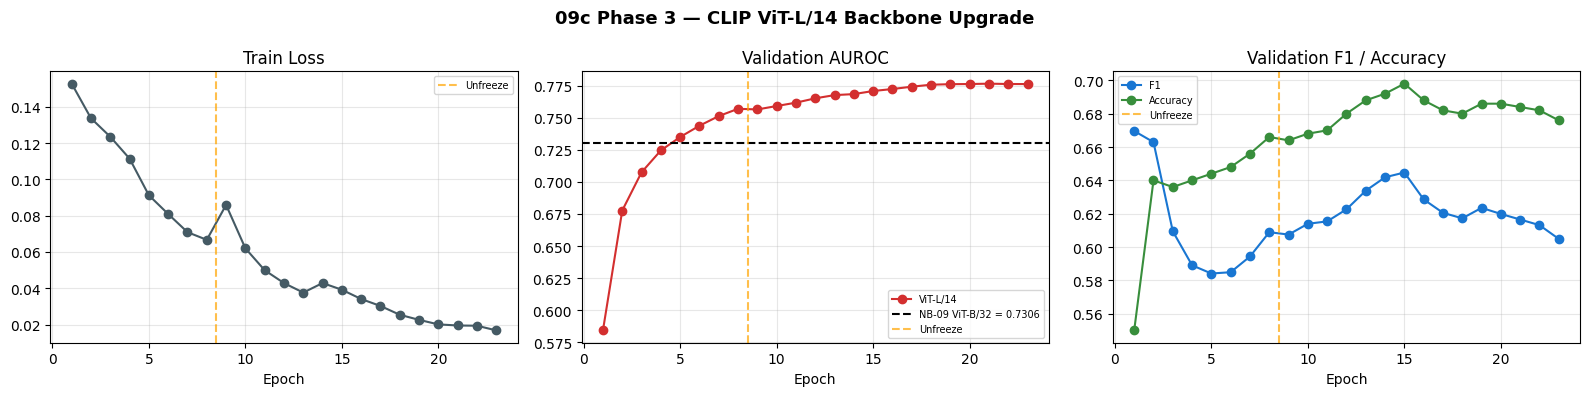

In [9]:
# ── Training Curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Combine phase 3a + 3b histories
all_loss  = history_3a['train_loss'] + history_3b['train_loss']
all_auroc = history_3a['val_auroc']  + history_3b['val_auroc']
all_f1    = history_3a['val_f1']     + history_3b['val_f1']
all_acc   = history_3a['val_accuracy'] + history_3b['val_accuracy']
epochs_all = range(1, len(all_loss) + 1)
phase_boundary = len(history_3a['train_loss']) + 0.5

axes[0].plot(epochs_all, all_loss, marker='o', color='#455A64')
axes[0].axvline(phase_boundary, ls='--', color='orange', alpha=0.7, label='Unfreeze')
axes[0].set_title('Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_all, all_auroc, marker='o', color='#D32F2F', label='ViT-L/14')
axes[1].axhline(REFERENCE_BEST_AUROC, ls='--', color='black', label=f'NB-09 ViT-B/32 = {REFERENCE_BEST_AUROC}')
axes[1].axvline(phase_boundary, ls='--', color='orange', alpha=0.7, label='Unfreeze')
axes[1].set_title('Validation AUROC')
axes[1].set_xlabel('Epoch')
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.3)

axes[2].plot(epochs_all, all_f1, marker='o', color='#1976D2', label='F1')
axes[2].plot(epochs_all, all_acc, marker='o', color='#388E3C', label='Accuracy')
axes[2].axvline(phase_boundary, ls='--', color='orange', alpha=0.7, label='Unfreeze')
axes[2].set_title('Validation F1 / Accuracy')
axes[2].set_xlabel('Epoch')
axes[2].legend(fontsize=7)
axes[2].grid(alpha=0.3)

plt.suptitle('09c Phase 3 \u2014 CLIP ViT-L/14 Backbone Upgrade', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '09c_vitl14_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Ensemble: ViT-L/14 + ViT-B/32 (NB-09)

Average the predicted probabilities from both models. Different backbones capture different patterns, so the ensemble benefits from model diversity even when individual scores are similar.

In [10]:
from sklearn.metrics import roc_curve

@torch.no_grad()
def get_probs(mdl, loader):
    mdl.eval()
    all_probs, all_labels = [], []
    for batch in loader:
        pv  = batch['pixel_values'].to(DEVICE)
        ids = batch['input_ids'].to(DEVICE)
        am  = batch['attention_mask'].to(DEVICE)
        with autocast(enabled=(DEVICE.type == 'cuda')):
            logits, _, _ = mdl(pv, ids, am)
        probs = torch.softmax(logits.float(), dim=-1)[:, 1]
        all_probs.extend(probs.cpu().numpy().tolist())
        all_labels.extend(batch['label'].numpy().tolist())
    return np.array(all_probs), np.array(all_labels)


# ── ViT-L/14 probs ───────────────────────────────────────────────────
vitl_ckpt = OUTPUT_DIR / 'vitl14_unfrozen_best.pt'
if vitl_ckpt.exists():
    state = torch.load(vitl_ckpt, map_location='cpu', weights_only=True)
    model.load_state_dict(state, strict=True)
    model = model.to(DEVICE)
    print(f'Loaded ViT-L/14 checkpoint: {vitl_ckpt}')
vitl_probs, labels = get_probs(model, dev_loader)
vitl_auroc = roc_auc_score(labels, vitl_probs)
print(f'ViT-L/14 AUROC: {vitl_auroc:.4f}')

# ── Free ViT-L/14 from GPU before loading ViT-B/32 ───────────────────
del model
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    import gc; gc.collect()
print('ViT-L/14 released from GPU.')


# ── ViT-B/32 probs (from NB-09 checkpoint) ───────────────────────────
# Build a separate ViT-B/32 model
def find_local_b32(model_name='clip-vit-base-patch32'):
    if ON_KAGGLE:
        for root in sorted(Path('/kaggle/input').rglob(model_name)):
            if (root / 'config.json').exists():
                print(f'Found local ViT-B/32: {root}')
                return str(root)
    return 'openai/clip-vit-base-patch32'

VITB_CFG = {
    'clip_model': find_local_b32(),
    'embed_dim': 512,
    'num_heads': 4,
    'dropout': 0.3,
    'max_text_len': 77,
}


class CLIPEncoderB32(nn.Module):
    def __init__(self):
        super().__init__()
        self.clip = CLIPModel.from_pretrained(VITB_CFG['clip_model'])
        for p in self.clip.parameters():
            p.requires_grad_(False)

    def forward(self, pixel_values, input_ids, attention_mask):
        i = F.normalize(_ensure_tensor(
            self.clip.get_image_features(pixel_values=pixel_values)), dim=-1)
        t = F.normalize(_ensure_tensor(
            self.clip.get_text_features(input_ids=input_ids, attention_mask=attention_mask)), dim=-1)
        return i, t


class HatefulMemeClassifierB32(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = CLIPEncoderB32()
        self.fusion  = CrossAttentionFusion(
            d=VITB_CFG['embed_dim'], heads=VITB_CFG['num_heads'], drop=VITB_CFG['dropout'])
        self.head    = ClassificationHead(
            d=VITB_CFG['embed_dim'] * 2, drop=VITB_CFG['dropout'])

    def forward(self, pixel_values, input_ids, attention_mask):
        i, t = self.encoder(pixel_values, input_ids, attention_mask)
        fused, ia, ta = self.fusion(i, t)
        return self.head(fused), ia, ta


# Note: ClassificationHead d=1024 needs override since default is 1536 now
# We redefine inline to avoid conflict
class ClassificationHeadB32(nn.Module):
    def __init__(self, d=1024, drop=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 256), nn.GELU(), nn.Dropout(drop),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(drop),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        return self.net(x)


class HatefulMemeClassifierB32(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = CLIPEncoderB32()
        d = VITB_CFG['embed_dim']
        self.fusion = CrossAttentionFusion(d=d, heads=VITB_CFG['num_heads'], drop=VITB_CFG['dropout'])
        self.head   = ClassificationHeadB32(d=d * 2, drop=VITB_CFG['dropout'])

    def forward(self, pixel_values, input_ids, attention_mask):
        i, t = self.encoder(pixel_values, input_ids, attention_mask)
        fused, ia, ta = self.fusion(i, t)
        return self.head(fused), ia, ta


# Find NB-09 checkpoint
def find_checkpoint(name):
    search_roots = []
    if ON_KAGGLE and Path('/kaggle/input').exists():
        search_roots.append(Path('/kaggle/input'))
    search_roots.extend([BASE_OUTPUT_DIR, OUTPUT_DIR, Path.cwd() / 'outputs'])
    for root in search_roots:
        if not root.exists():
            continue
        for match in root.rglob(name):
            return match
    return None


vitb_probs = None
vitb_ckpt = find_checkpoint('cross_attention_phase2_best.pt')
if vitb_ckpt is None:
    vitb_ckpt = find_checkpoint('cross_attention_best.pt')

if vitb_ckpt is not None:
    print(f'\nLoading ViT-B/32 model from: {vitb_ckpt}')
    # Need ViT-B/32 processor for this model
    processor_b32 = CLIPProcessor.from_pretrained(VITB_CFG['clip_model'])
    dev_ds_b32 = MemeDataset(dev_df, DATA_DIR, processor_b32, training=False)
    dev_loader_b32 = DataLoader(dev_ds_b32, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

    model_b32 = HatefulMemeClassifierB32()
    # Unfreeze to match NB-09's saved state_dict keys
    clip_b32 = model_b32.encoder.clip
    for layer in clip_b32.vision_model.encoder.layers[-3:]:
        for p in layer.parameters(): p.requires_grad_(True)
    for layer in clip_b32.text_model.encoder.layers[-3:]:
        for p in layer.parameters(): p.requires_grad_(True)
    for module in [clip_b32.vision_model.post_layernorm, clip_b32.text_model.final_layer_norm,
                   clip_b32.visual_projection, clip_b32.text_projection]:
        for p in module.parameters(): p.requires_grad_(True)

    state_b32 = torch.load(vitb_ckpt, map_location='cpu', weights_only=True)
    model_b32.load_state_dict(state_b32, strict=True)
    model_b32 = model_b32.to(DEVICE)
    print('ViT-B/32 model loaded.')

    vitb_probs, _ = get_probs(model_b32, dev_loader_b32)
    vitb_auroc = roc_auc_score(labels, vitb_probs)
    print(f'ViT-B/32 AUROC: {vitb_auroc:.4f}')

    # Free memory
    del model_b32
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
else:
    print('NB-09 checkpoint not found. Attach it as a Kaggle input to enable ensemble.')
    print('Skipping ensemble.')

Loaded ViT-L/14 checkpoint: /kaggle/working/vitl14_unfrozen_best.pt


/tmp/ipykernel_25/1289326432.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):


ViT-L/14 AUROC: 0.7765
ViT-L/14 released from GPU.
NB-09 checkpoint not found. Attach it as a Kaggle input to enable ensemble.
Skipping ensemble.


In [11]:
# ── Ensemble & Threshold Optimization ─────────────────────────────────
print('=' * 60)
print('INDIVIDUAL RESULTS')
print(f'  ViT-L/14 AUROC             : {vitl_auroc:.4f}')

if vitb_probs is not None:
    vitb_auroc_val = roc_auc_score(labels, vitb_probs)
    print(f'  ViT-B/32 AUROC (NB-09)     : {vitb_auroc_val:.4f}')

    # Grid search over ensemble weights
    best_ens_auroc = 0.0
    best_alpha = 0.5
    for alpha in np.arange(0.1, 0.95, 0.05):
        ens_probs = alpha * vitl_probs + (1 - alpha) * vitb_probs
        ens_auroc = roc_auc_score(labels, ens_probs)
        if ens_auroc > best_ens_auroc:
            best_ens_auroc = ens_auroc
            best_alpha = alpha

    ens_probs_final = best_alpha * vitl_probs + (1 - best_alpha) * vitb_probs
    ens_auroc_final = roc_auc_score(labels, ens_probs_final)

    print(f'\nENSEMBLE (alpha={best_alpha:.2f} * ViT-L + {1-best_alpha:.2f} * ViT-B)')
    print(f'  Ensemble AUROC             : {ens_auroc_final:.4f}')
else:
    ens_probs_final = vitl_probs
    ens_auroc_final = vitl_auroc
    best_alpha = 1.0
    print('  (No ViT-B/32 checkpoint \u2014 using ViT-L/14 only)')

# Optimal threshold (F1)
best_f1, best_thresh = 0, 0.5
for t in np.arange(0.25, 0.75, 0.01):
    preds = (ens_probs_final >= t).astype(int)
    f = f1_score(labels, preds, pos_label=1)
    if f > best_f1:
        best_f1, best_thresh = f, t

final_preds = (ens_probs_final >= best_thresh).astype(int)
final_f1  = f1_score(labels, final_preds, pos_label=1)
final_acc = accuracy_score(labels, final_preds)

print(f'\nOPTIMAL THRESHOLD')
print(f'  Threshold                  : {best_thresh:.2f}')
print(f'  F1 @ optimal               : {final_f1:.4f}')
print(f'  Accuracy @ optimal         : {final_acc:.4f}')

print()
print('=' * 60)
print('COMPARISON')
print(f'  NB-08 baseline AUROC       : 0.7017')
print(f'  NB-09 ViT-B/32 AUROC       : {REFERENCE_BEST_AUROC}')
print(f'  NB-09c ViT-L/14 AUROC      : {vitl_auroc:.4f}')
print(f'  NB-09c Ensemble AUROC      : {ens_auroc_final:.4f}')
print(f'  Best AUROC delta vs NB-09  : {max(vitl_auroc, ens_auroc_final) - REFERENCE_BEST_AUROC:+.4f}')
print('=' * 60)

best_overall = max(vitl_auroc, ens_auroc_final)
if best_overall > REFERENCE_BEST_AUROC:
    if ens_auroc_final >= vitl_auroc:
        print(f'\nEnsemble is best. Use both checkpoints for notebook 10.')
    else:
        print(f'\nViT-L/14 standalone is best. Use vitl14_unfrozen_best.pt for notebook 10.')
else:
    print(f'\nNB-09 ViT-B/32 remains the best checkpoint. Use cross_attention_phase2_best.pt.')

INDIVIDUAL RESULTS
  ViT-L/14 AUROC             : 0.7765
  (No ViT-B/32 checkpoint — using ViT-L/14 only)

OPTIMAL THRESHOLD
  Threshold                  : 0.27
  F1 @ optimal               : 0.7230
  Accuracy @ optimal         : 0.7180

COMPARISON
  NB-08 baseline AUROC       : 0.7017
  NB-09 ViT-B/32 AUROC       : 0.7306
  NB-09c ViT-L/14 AUROC      : 0.7765
  NB-09c Ensemble AUROC      : 0.7765
  Best AUROC delta vs NB-09  : +0.0459

Ensemble is best. Use both checkpoints for notebook 10.
